In [1]:
from google.colab import files

uploaded = files.upload()


Saving Cleaned_Data.csv to Cleaned_Data.csv


In [2]:
## Importing Pandas
import pandas as pd

## Loading the file
df = pd.read_csv('Cleaned_Data.csv')

## Looking at the first 5 rows
df.head(10)

,ID,State,Date,Day_of_Week,Time_of_Day,Weather_Conditions,Road_Conditions,Light_Conditions,Type_of_Road,Type_of_Junction,...,Num_Vehicles_Involved,Num_Casualties,Speed_Limit,Distance_to_Nearest_Hospital,Distance_to_Nearest_Police_Station,Visibility,Road_Width,Road_Surface_Friction_Coefficient,Vehicle_Speed,Time_Taken_for_Emergency_Response
0,165433,Connecticut,2024-02-20 05:46:20,Tuesday,19:59:02,Rainy,Muddy,Daylight,Street,T-Junction,...,2,3,57.0,3.303606,3.139351,485.649011,4.886202,0.904971,45.0,25.152781
1,165434,Massachusetts,2024-01-09 05:08:31,Wednesday,21:28:51,Sunny,Muddy,Daylight,Highway,Intersection,...,1,0,55.0,2.715327,3.634593,616.979936,4.677592,0.949236,41.0,23.163817
2,165435,Wyoming,2024-02-20 08:26:27,Thursday,18:04:26,Snowy,Snowy,Dawn,Street,Underpass,...,3,1,38.0,4.811429,9.631561,838.741654,9.926058,0.184447,64.0,6.697750
3,165436,Hawaii,2024-01-15 03:23:47,Sunday,16:51:02,Snowy,Icy,Daylight,Street,Intersection,...,5,0,59.0,6.976968,2.334468,842.441019,4.351822,0.195811,49.0,6.595036
4,165437,Oklahoma,2024-02-10 10:17:29,Tuesday,14:19:19,Foggy,Icy,Night,Rural,T-Junction,...,2,0,53.0,3.724599,4.359620,905.620262,6.626862,0.954821,81.0,22.913128
5,165438,Minnesota,2024-02-23 22:04:48,Monday,00:14:21,Foggy,Snowy,Dawn,Urban,T-Junction,...,4,2,41.0,6.731335,6.917152,550.071522,9.254612,0.463229,37.0,6.905080
6,165439,Wyoming,2024-02-19 19:41:33,Saturday,10:21:34,Stormy,Icy,Daylight,Street,Crossroads,...,1,2,65.0,8.431762,0.674836,859.038058,9.691997,0.552160,80.0,17.498544
7,165440,Minnesota,2024-01-25 16:51:14,Tuesday,02:01:40,Rainy,Icy,Daylight,Urban,Underpass,...,4,1,68.0,6.056827,9.926590,700.929963,4.922312,0.524377,0.0,26.812323
8,165441,Nevada,2024-01-07 06:48:41,Wednesday,06:09:08,Rainy,Wet,Dusk,Highway,Overpass,...,4,0,59.0,6.010958,7.872237,892.720874,9.329545,0.756147,63.0,20.442677
9,165442,North Dakota,2024-01-01 06:22:29,Tuesday,22:33:51,Sunny,Icy,Dawn,Street,Overpass,...,1,3,30.0,4.781272,5.136493,934.029620,8.650907,0.218058,45.0,7.766432


In [3]:
Max_Speed = df['Vehicle_Speed'].max()
print(Max_Speed)

100.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 23 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ID                                  1610 non-null   int64  
 1   State                               1610 non-null   object 
 2   Date                                1610 non-null   object 
 3   Day_of_Week                         1610 non-null   object 
 4   Time_of_Day                         1610 non-null   object 
 5   Weather_Conditions                  1610 non-null   object 
 6   Road_Conditions                     1610 non-null   object 
 7   Light_Conditions                    1610 non-null   object 
 8   Type_of_Road                        1610 non-null   object 
 9   Type_of_Junction                    1610 non-null   object 
 10  Type_of_Accident                    1610 non-null   object 
 11  Vehicle_Type                        1610 no

In [5]:
df.isna().sum()

,0
ID,0
State,0
Date,0
Day_of_Week,0
Time_of_Day,0
Weather_Conditions,0
Road_Conditions,0
Light_Conditions,0
Type_of_Road,0
Type_of_Junction,0


In [6]:
## Let's Fill the Categorical Columns with "Unknown"
## Columns Weather_Condition and Type_of_junction has categorical value.

## Fixing Categorical Missing Values
df['Weather_Conditions'] = df['Weather_Conditions'].fillna('Unknown')
df['Type_of_Junction'] = df['Type_of_Junction'].fillna('Unknown')

In [7]:
## Fixing Numerical Missing Value

Median_Value = df['Speed_Limit'].median()
print(Median_Value)

## Taking the empty cell of Speed Limit with median value.
df['Speed_Limit'] = df['Speed_Limit'].fillna(Median_Value)

## To check if the cell is filled with a mix of data.
df.sample(60)

50.0


,ID,State,Date,Day_of_Week,Time_of_Day,Weather_Conditions,Road_Conditions,Light_Conditions,Type_of_Road,Type_of_Junction,...,Num_Vehicles_Involved,Num_Casualties,Speed_Limit,Distance_to_Nearest_Hospital,Distance_to_Nearest_Police_Station,Visibility,Road_Width,Road_Surface_Friction_Coefficient,Vehicle_Speed,Time_Taken_for_Emergency_Response
502,165935,Hawaii,2024-02-13 15:32:37,Monday,03:19:43,Foggy,Icy,Daylight,Highway,Roundabout,...,1,3,51.0,6.875176,0.686011,404.323976,4.617631,0.664412,49.0,25.190936
1456,166889,South Carolina,2024-01-25 08:33:58,Wednesday,06:19:04,Sunny,Snowy,Night,Rural,Intersection,...,1,3,55.0,4.039904,0.862126,882.021861,4.868345,0.240522,48.0,15.041901
1477,166910,New Hampshire,2024-01-09 14:33:30,Wednesday,15:40:58,Sunny,Muddy,Dawn,Freeway,Crossroads,...,5,2,61.0,1.064574,9.228732,653.095848,9.936305,0.162451,3.0,19.529708
1124,166557,New Hampshire,2024-01-21 10:25:25,Thursday,05:06:59,Unknown,Muddy,Daylight,Highway,Intersection,...,3,0,35.0,9.378388,6.511942,776.800531,6.623199,0.387846,20.0,8.481969
631,166064,Georgia,2024-01-03 21:33:37,Friday,21:34:52,Snowy,Muddy,Dawn,Freeway,Underpass,...,3,0,66.0,1.199866,2.919204,256.703738,6.623199,0.734548,4.0,17.498544
898,166331,Colorado,2024-01-18 18:34:16,Friday,21:07:02,Foggy,Muddy,Dusk,Freeway,Underpass,...,5,3,52.0,3.109848,8.093060,675.615375,4.362762,0.266310,91.0,27.125510
127,165560,Mississippi,2024-01-29 05:06:33,Wednesday,06:32:16,Sunny,Muddy,Dusk,Rural,Underpass,...,1,3,44.0,6.410956,9.930100,661.768743,8.076880,0.544304,83.0,17.498544
459,165892,South Dakota,2024-02-01 02:03:52,Sunday,04:24:14,Snowy,Dry,Dusk,Rural,Underpass,...,2,0,31.0,3.575518,6.621545,957.576538,7.199756,0.851900,29.0,9.439004
868,166301,Delaware,2024-02-02 00:38:28,Wednesday,19:23:39,Foggy,Dry,Daylight,Freeway,Crossroads,...,5,1,50.0,3.438563,4.666420,156.882385,8.092154,0.939539,49.0,14.133482
1392,166825,Arkansas,2024-01-21 14:41:13,Saturday,21:34:58,Unknown,Snowy,Daylight,Rural,Overpass,...,5,0,50.0,0.946860,4.629938,932.153736,3.387767,0.124983,52.0,17.498544


In [8]:
## For Columns Road_Width

Median_Value = df['Road_Width'].median()
print(Median_Value)


## filling the empty cell with median value.
df['Road_Width'] = df['Road_Width'].fillna(Median_Value)


## Checking a mix of data if the empty cell is filled with a median value.
df.sample(60)


6.6231986


,ID,State,Date,Day_of_Week,Time_of_Day,Weather_Conditions,Road_Conditions,Light_Conditions,Type_of_Road,Type_of_Junction,...,Num_Vehicles_Involved,Num_Casualties,Speed_Limit,Distance_to_Nearest_Hospital,Distance_to_Nearest_Police_Station,Visibility,Road_Width,Road_Surface_Friction_Coefficient,Vehicle_Speed,Time_Taken_for_Emergency_Response
1574,167007,North Carolina,2024-01-09 02:49:50,Monday,13:53:00,Snowy,Dry,Daylight,Street,Unknown,...,5,0,43.0,8.361804,2.825502,237.063600,5.703086,0.699627,42.0,10.033701
609,166042,Minnesota,2024-02-25 08:21:59,Tuesday,22:25:21,Stormy,Muddy,Dawn,Rural,Underpass,...,5,1,46.0,5.168736,5.860852,872.834477,7.094670,0.293304,58.0,18.098539
1094,166527,Kentucky,2024-01-28 20:55:52,Monday,04:44:36,Unknown,Icy,Night,Rural,Crossroads,...,4,3,54.0,0.143640,4.476721,243.239577,3.920945,0.998056,73.0,5.293709
1069,166502,Oklahoma,2024-02-16 23:15:10,Sunday,03:55:31,Rainy,Snowy,Daylight,Rural,Intersection,...,2,0,32.0,2.412167,8.348235,442.168554,5.244134,0.454902,35.0,15.376115
714,166147,Arkansas,2024-01-15 23:44:56,Saturday,21:30:36,Rainy,Muddy,Dawn,Freeway,Roundabout,...,2,2,48.0,5.554638,5.059018,365.251109,4.250639,0.241556,71.0,19.815491
737,166170,Maine,2024-02-22 17:11:12,Sunday,23:18:42,Foggy,Muddy,Daylight,Urban,T-Junction,...,4,2,37.0,3.657659,8.696016,848.827067,9.504733,0.169160,53.0,10.091089
1497,166930,Tennessee,2024-01-28 01:57:53,Sunday,20:13:06,Snowy,Snowy,Dusk,Rural,T-Junction,...,5,1,50.0,3.507343,4.595225,169.597680,6.203232,0.898410,20.0,23.595220
374,165807,South Dakota,2024-02-07 21:59:50,Monday,16:51:27,Rainy,Icy,Dusk,Rural,Underpass,...,3,1,46.0,2.811543,5.151249,831.329208,9.004800,0.280885,84.0,29.022357
1424,166857,Colorado,2024-02-08 17:27:02,Thursday,10:08:19,Unknown,Wet,Dawn,Freeway,Roundabout,...,5,1,49.0,0.985031,5.409805,871.272747,6.623199,0.218053,77.0,5.514099
1170,166603,Michigan,2024-01-05 23:53:11,Friday,02:52:57,Stormy,Wet,Daylight,Urban,Intersection,...,1,1,50.0,2.609226,6.311504,261.022775,9.159970,0.870058,81.0,16.945041


In [9]:
## For Columns 'Vehicle_Speed'

## Calculating  Median
Median_Value = df['Vehicle_Speed'].median()
print(Median_Value)

## Filling the empty cell with this Median_Value
df['Vehicle_Speed'] = df['Vehicle_Speed'].fillna(Median_Value)

## Printing random 60 row to check if the cells are filled or not
df.sample(60)

49.0


,ID,State,Date,Day_of_Week,Time_of_Day,Weather_Conditions,Road_Conditions,Light_Conditions,Type_of_Road,Type_of_Junction,...,Num_Vehicles_Involved,Num_Casualties,Speed_Limit,Distance_to_Nearest_Hospital,Distance_to_Nearest_Police_Station,Visibility,Road_Width,Road_Surface_Friction_Coefficient,Vehicle_Speed,Time_Taken_for_Emergency_Response
1333,166766,South Dakota,2024-01-31 10:56:23,Wednesday,09:07:23,Unknown,Dry,Dawn,Street,Overpass,...,5,2,35.0,9.062531,0.805915,273.783098,8.763404,0.267554,39.0,17.498544
1381,166814,Mississippi,2024-02-01 00:07:00,Friday,22:05:02,Stormy,Muddy,Dusk,Urban,Overpass,...,2,0,50.0,9.692716,4.334031,783.284001,6.513293,0.297456,22.0,28.384100
571,166004,Illinois,2024-02-09 14:59:36,Thursday,09:31:12,Foggy,Dry,Daylight,Street,Unknown,...,5,2,40.0,8.503972,8.795904,638.070615,6.947798,0.646211,0.0,12.485197
201,165634,Pennsylvania,2024-02-05 00:47:06,Tuesday,18:50:54,Stormy,Snowy,Daylight,Street,Overpass,...,3,1,37.0,6.676523,3.342766,912.870537,8.779940,0.460004,78.0,22.215016
316,165749,Oregon,2024-02-19 15:41:04,Friday,23:29:31,Stormy,Wet,Daylight,Highway,Underpass,...,4,2,38.0,0.975044,3.962603,801.329161,5.746324,0.313375,74.0,29.302194
1131,166564,Delaware,2024-02-24 06:55:52,Friday,11:37:28,Sunny,Dry,Dusk,Rural,T-Junction,...,5,0,51.0,9.987176,3.020371,668.114025,9.677152,0.842305,11.0,11.613228
1310,166743,Arkansas,2024-01-02 06:29:30,Monday,20:38:08,Rainy,Snowy,Daylight,Rural,Intersection,...,4,3,34.0,0.648982,6.199740,493.619238,6.623199,0.502167,92.0,22.073104
894,166327,Louisiana,2024-02-03 23:05:25,Thursday,13:35:26,Sunny,Dry,Dusk,Freeway,Intersection,...,5,0,30.0,0.446511,0.206458,548.201970,8.113854,0.183680,20.0,7.209006
1420,166853,Idaho,2024-01-06 21:28:00,Saturday,08:31:05,Rainy,Wet,Night,Freeway,Intersection,...,1,1,32.0,9.347619,5.393490,450.828056,5.315601,0.763195,7.0,14.771294
526,165959,New Mexico,2024-02-10 16:42:40,Saturday,13:35:22,Rainy,Muddy,Dawn,Rural,Crossroads,...,5,0,44.0,3.989518,0.124514,782.589034,8.608308,0.511070,73.0,27.460467


In [10]:
## Let's Fix For Column 'Time_Taken_for_Emergency_Response'

## Calculating MEdian
Median_Value = df['Time_Taken_for_Emergency_Response'].median()
print(Median_Value)

## Filling the empty cell with this median value
df['Time_Taken_for_Emergency_Response'] = df['Time_Taken_for_Emergency_Response'].fillna(Median_Value)

## Printing random 60 row to check if the cells are filled or not
df.sample(60)

17.498543705


,ID,State,Date,Day_of_Week,Time_of_Day,Weather_Conditions,Road_Conditions,Light_Conditions,Type_of_Road,Type_of_Junction,...,Num_Vehicles_Involved,Num_Casualties,Speed_Limit,Distance_to_Nearest_Hospital,Distance_to_Nearest_Police_Station,Visibility,Road_Width,Road_Surface_Friction_Coefficient,Vehicle_Speed,Time_Taken_for_Emergency_Response
465,165898,Washington,2024-01-09 14:10:24,Saturday,22:52:26,Stormy,Dry,Night,Rural,Roundabout,...,5,0,50.0,0.410072,7.363836,303.002323,3.823584,0.185945,24.0,6.263129
547,165980,Oklahoma,2024-02-02 11:49:37,Tuesday,09:26:35,Stormy,Wet,Dawn,Urban,Crossroads,...,2,0,35.0,6.452066,5.528698,445.404371,6.623199,0.200112,82.0,25.945472
460,165893,Missouri,2024-01-25 11:29:39,Thursday,10:22:35,Snowy,Muddy,Daylight,Freeway,Intersection,...,4,1,33.0,3.958248,1.915929,844.757074,5.957407,0.481952,21.0,18.910003
735,166168,Ohio,2024-02-26 16:07:35,Saturday,01:28:48,Sunny,Muddy,Daylight,Rural,Unknown,...,4,2,38.0,4.114972,0.885166,394.618196,3.284455,0.280689,77.0,9.584679
680,166113,Maine,2024-01-17 17:39:43,Sunday,21:29:41,Rainy,Dry,Daylight,Highway,Overpass,...,5,2,35.0,2.285692,4.464218,775.935316,9.759526,0.964201,9.0,21.583732
658,166091,Pennsylvania,2024-01-27 14:25:06,Monday,17:47:17,Rainy,Wet,Dusk,Urban,Unknown,...,1,3,59.0,9.024791,8.902090,309.552036,9.919238,0.849075,48.0,18.050454
191,165624,Georgia,2024-01-07 10:46:37,Saturday,12:03:58,Foggy,Icy,Dusk,Urban,Unknown,...,3,1,37.0,4.711727,0.411106,124.543892,8.194232,0.178143,17.0,9.298544
1363,166796,Delaware,2024-02-25 08:21:09,Wednesday,05:33:19,Sunny,Snowy,Dawn,Street,Crossroads,...,3,2,46.0,6.480116,9.938345,680.501678,3.633435,0.282082,93.0,7.840636
1463,166896,Ohio,2024-01-31 04:05:13,Friday,22:06:19,Rainy,Icy,Daylight,Rural,Crossroads,...,1,1,70.0,2.547787,0.585990,950.035996,5.299034,0.565314,49.0,16.370020
271,165704,North Dakota,2024-02-04 17:35:56,Sunday,07:53:13,Rainy,Dry,Dawn,Urban,Crossroads,...,2,2,50.0,7.742512,7.184034,271.276714,6.318974,0.244800,90.0,28.296514


In [11]:
## Let's Fix Inconsistent Categories

## Making "rainy" into "Rainy" and "STREET" into "Street"

df['Weather_Conditions'] = df['Weather_Conditions'].str.strip().str.title()


df['Type_of_Road'] = df['Type_of_Road'].str.strip().str.title()


## .strip() removes accidental space at the beginning or the end of the text. And, .title() converts the text into title case ( first letter uppercase and the rest Lowercase)

In [12]:
df.describe()

,ID,Num_Vehicles_Involved,Num_Casualties,Speed_Limit,Distance_to_Nearest_Hospital,Distance_to_Nearest_Police_Station,Visibility,Road_Width,Road_Surface_Friction_Coefficient,Vehicle_Speed,Time_Taken_for_Emergency_Response
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,166237.500000,3.062112,1.444099,50.130435,5.062241,5.049247,553.774075,6.545803,0.549663,49.830435,17.743425
std,464.911282,1.412848,1.155813,11.291125,2.890145,2.800700,258.589644,1.911251,0.259722,27.624116,6.862030
min,165433.000000,1.000000,0.000000,30.000000,0.113713,0.100520,100.224514,3.000363,0.100261,0.000000,5.032373
25%,165835.250000,2.000000,0.000000,41.000000,2.549658,2.708608,327.701610,4.939065,0.315058,28.000000,12.464749
50%,166237.500000,3.000000,1.000000,50.000000,5.151083,4.977115,557.361549,6.623199,0.550753,49.000000,17.498544
75%,166639.750000,4.000000,3.000000,59.000000,7.563470,7.474726,781.561590,8.113626,0.774580,73.000000,23.534142
max,167042.000000,5.000000,3.000000,70.000000,9.999620,9.998113,999.931342,9.996583,0.999489,100.000000,29.981212


In [13]:
### Let's Create 3 Visualization

import matplotlib.pyplot as plt

import seaborn as sns

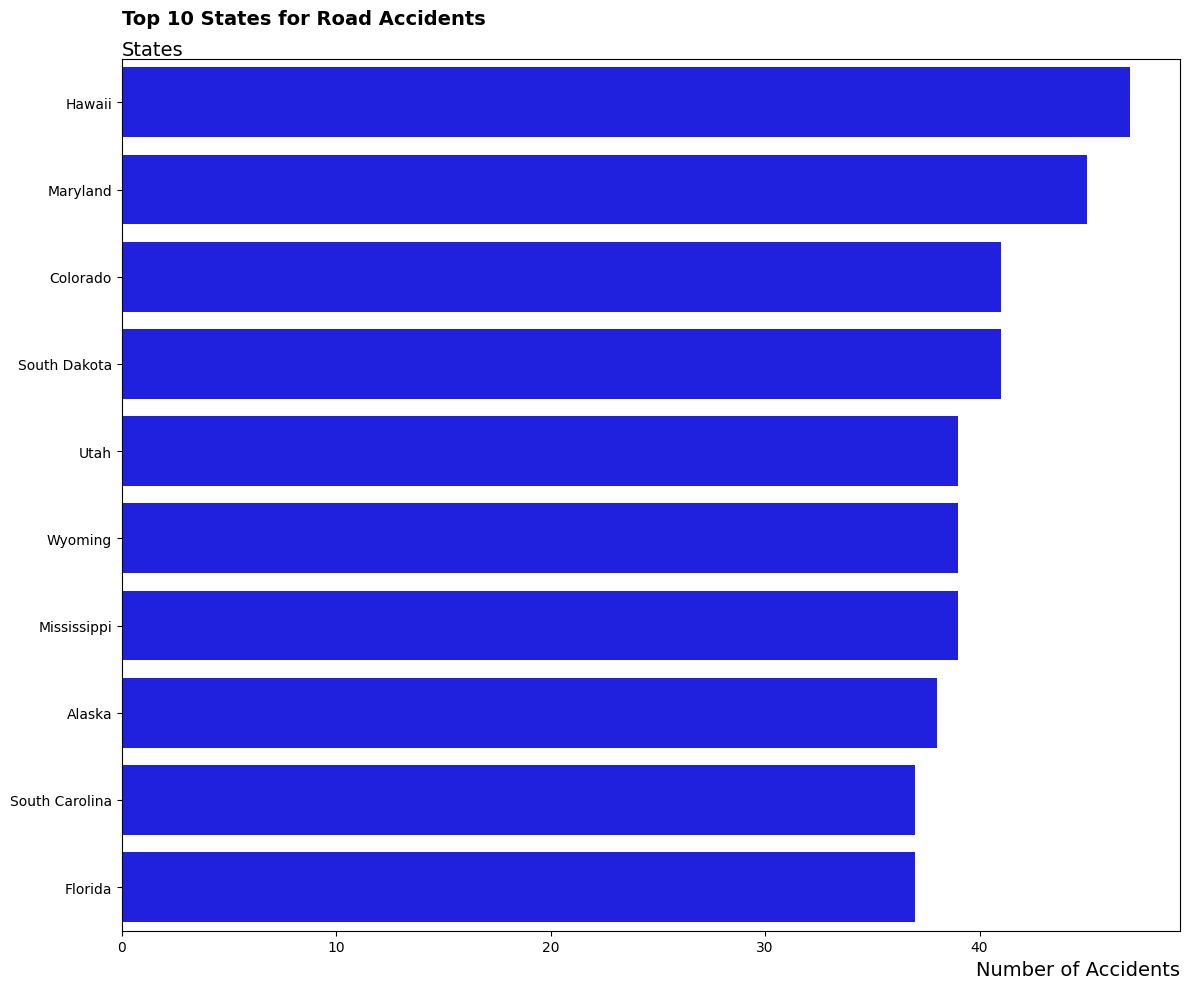

In [14]:
## Let's find out  Which states have the most accidents?


if 'State' in df.columns:
    plt.figure(figsize=(12, 10))
    sns.countplot(data=df, y='State', order=df['State'].value_counts().index[:10], color='blue')
    plt.title('Top 10 States for Road Accidents', loc='left',fontsize=14, fontweight='bold', pad=25)
    plt.xlabel('Number of Accidents', fontsize=14, loc='right')
    plt.ylabel('States', rotation=0, loc='top', labelpad=-125, fontsize=14)
    plt.tight_layout()
    plt.savefig('top_10_states_accidents.png')


else:
    print("Column 'State' not found. Available columns:", df.columns.tolist())

In [15]:
## Noticed

"""
By isolating the Top 10 states, I can clearly identify which regions are 'hotspots' for accidents in this dataset. This helps prioritize where safety interventions or further infrastructure studies are most needed.

The horizontal orientation allows for a clear ranking. If there is a large gap between the top state and the second state, it suggests either a significantly higher population or a potential bias in how accidents are reported in that specific region.



"""

"\nBy isolating the Top 10 states, I can clearly identify which regions are 'hotspots' for accidents in this dataset. This helps prioritize where safety interventions or further infrastructure studies are most needed.\n\nThe horizontal orientation allows for a clear ranking. If there is a large gap between the top state and the second state, it suggests either a significantly higher population or a potential bias in how accidents are reported in that specific region.\n\n\n\n"

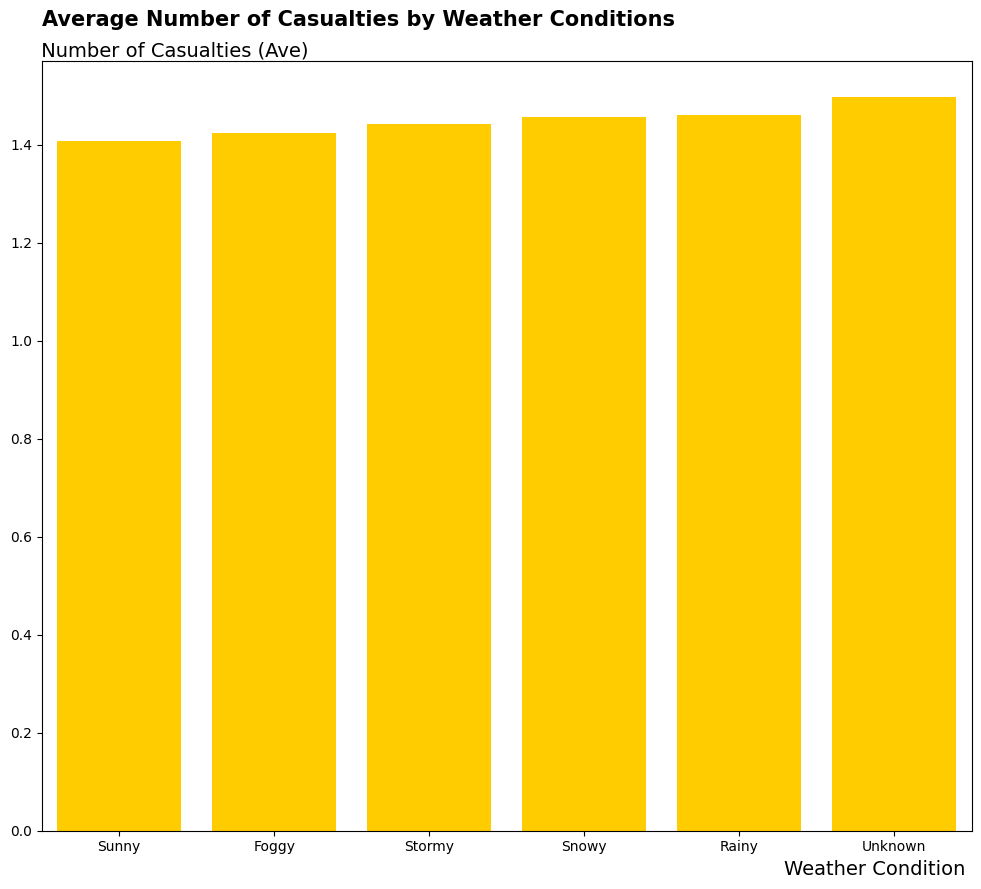

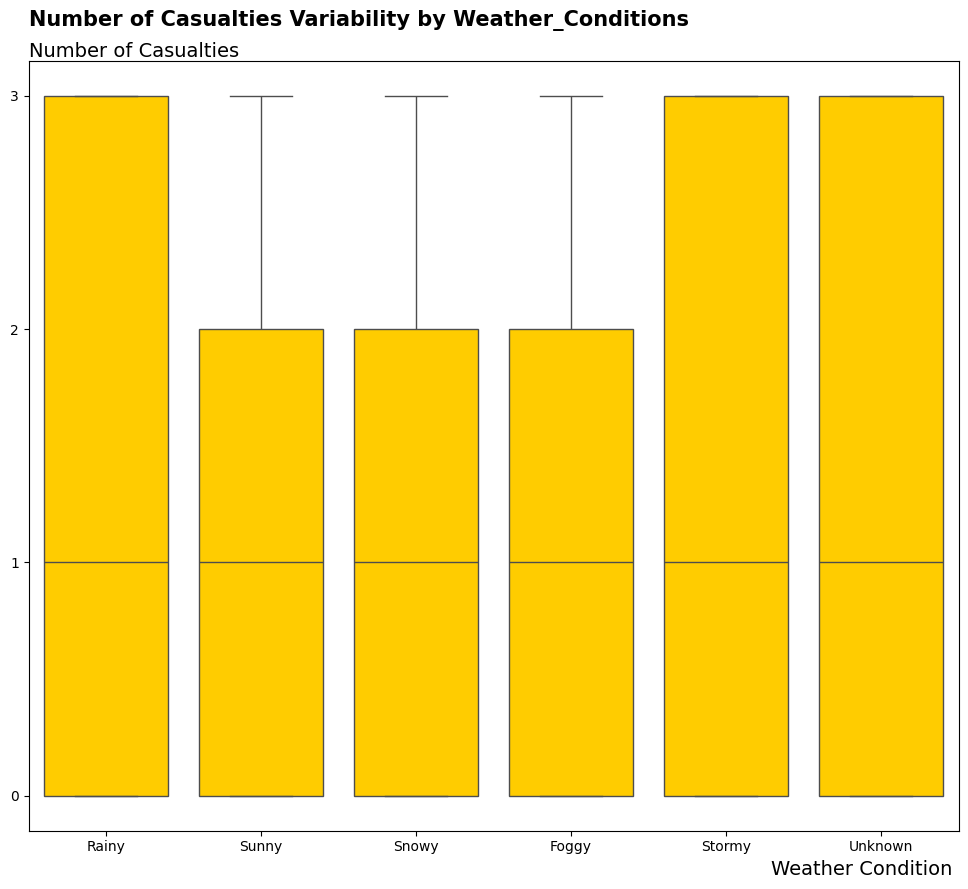

In [16]:
## Let's find out Does Weather conditions affect the number of casualties?
from matplotlib.ticker import MaxNLocator

weather_order = df.groupby('Weather_Conditions')['Num_Casualties'].mean().sort_values(ascending=True).index


plt.figure(figsize=(12,10))
sns.barplot(data=df, x='Weather_Conditions', y='Num_Casualties', order=weather_order, color='#FFCC00', saturation=5, errorbar=None)
plt.title('Average Number of Casualties by Weather Conditions', pad=25, loc='left' ,fontsize=15, fontweight='bold')
plt.ylabel(" Number of Casualties (Ave)", rotation=0, loc='top', labelpad=-215, fontsize=14)
plt.xlabel("Weather Condition ", fontsize=14, loc='right')

plt.show()




plt.figure(figsize=(12, 10))
sns.boxplot(data=df, x='Weather_Conditions', y='Num_Casualties'
            , color='#FFCC00', saturation=5)
plt.title('Number of Casualties Variability by Weather_Conditions ', loc='left', pad=25,fontsize=15, fontweight='bold')
plt.ylabel("Number of Casualties", rotation=0, loc='top', labelpad=-165, fontsize=14)
plt.xlabel("Weather Condition ", fontsize=14, loc='right')



ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(integer=True))


plt.show()

In [17]:
## Discovery

"""
While we might expect 'Clear' or 'Sunny' days to be the safest, the bar chart reveals that the average number of casualties remains relatively consistent across all weather types. This suggests that while weather may cause more accidents, it doesn't necessarily make each individual accident more deadly.


Misleading Encoding:

The upper graph is misleading because it only shows the mean. It suggests that Stormy weather is significantly more dangerous than Sunny weather, but it hides whether this is based on a few extreme accidents or a consistent trend.

The another graph I have made a Boxplot which is excellent for showing that casualties vary wildly from 0 to 3 regardless of the weather. It prevents the viewer from thinking the average is the only thing that happens.

"""

"\nWhile we might expect 'Clear' or 'Sunny' days to be the safest, the bar chart reveals that the average number of casualties remains relatively consistent across all weather types. This suggests that while weather may cause more accidents, it doesn't necessarily make each individual accident more deadly.\n\n\nMisleading Encoding:\n\nThe upper graph is misleading because it only shows the mean. It suggests that Stormy weather is significantly more dangerous than Sunny weather, but it hides whether this is based on a few extreme accidents or a consistent trend.\n\nThe another graph I have made a Boxplot which is excellent for showing that casualties vary wildly from 0 to 3 regardless of the weather. It prevents the viewer from thinking the average is the only thing that happens.\n\n"

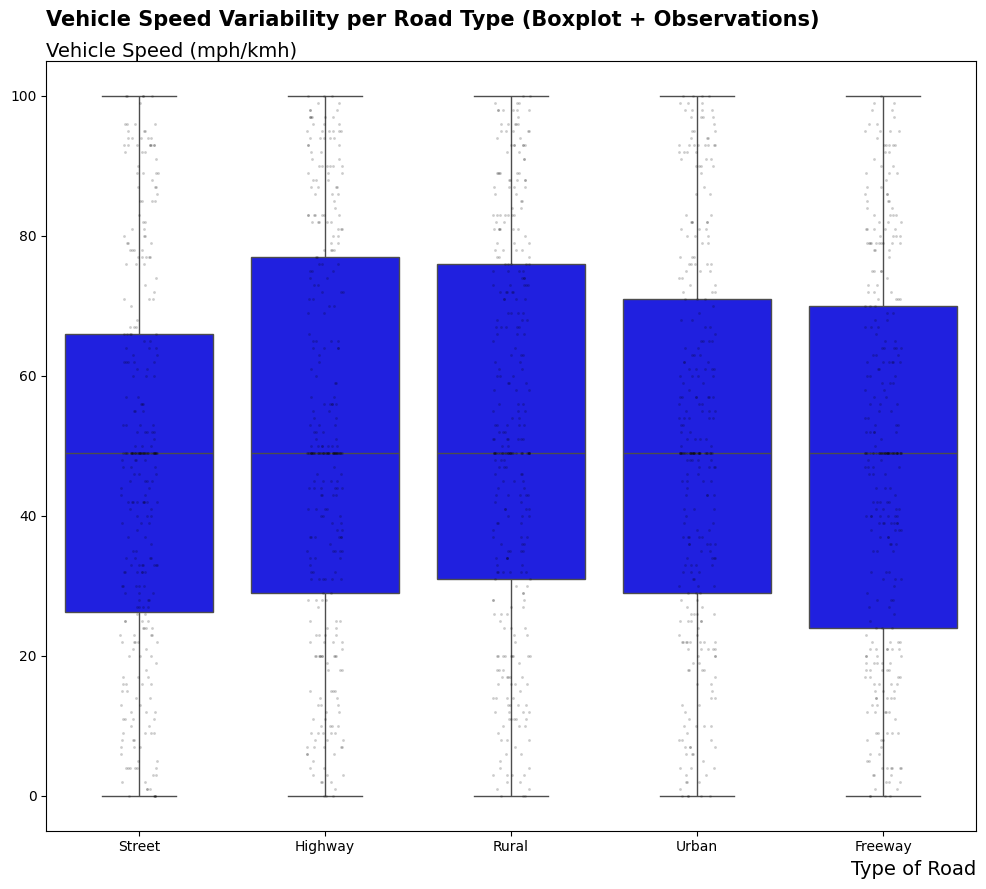

In [18]:

## Boxplot + Stripplot (to show variability and density)

# Dropping NaNs for this specific plot
speed_data = df[['Type_of_Road', 'Vehicle_Speed']].dropna()

plt.figure(figsize=(12, 10))
sns.boxplot(data=speed_data, x='Type_of_Road', y='Vehicle_Speed', showfliers=False, color='blue')

sns.stripplot(data=speed_data, x='Type_of_Road', y='Vehicle_Speed', color='black', size=2, alpha=0.2, jitter=True)

plt.title('Vehicle Speed Variability per Road Type (Boxplot + Observations)' , loc='left', pad=25 , fontsize=15, fontweight='bold')
plt.ylabel('Vehicle Speed (mph/kmh)', rotation=0, loc='top', labelpad=-207, fontsize=14)
plt.xlabel('Type of Road', loc='right', fontsize=14)


plt.show()

In [19]:
## Noticed

"""
I notice that the median vehicle speed is significantly higher on Highways compared to Urban streets, which is expected. However, the median speed on Rural roads is surprisingly close to Highway speeds.

The 'box' for Streets is much shorter than the others. This indicates that speeds in urban areas are more consistent (likely due to traffic or stoplights), whereas Highway speeds have a much wider spread

"""

"\nI notice that the median vehicle speed is significantly higher on Highways compared to Urban streets, which is expected. However, the median speed on Rural roads is surprisingly close to Highway speeds.\n\nThe 'box' for Streets is much shorter than the others. This indicates that speeds in urban areas are more consistent (likely due to traffic or stoplights), whereas Highway speeds have a much wider spread\n\n"

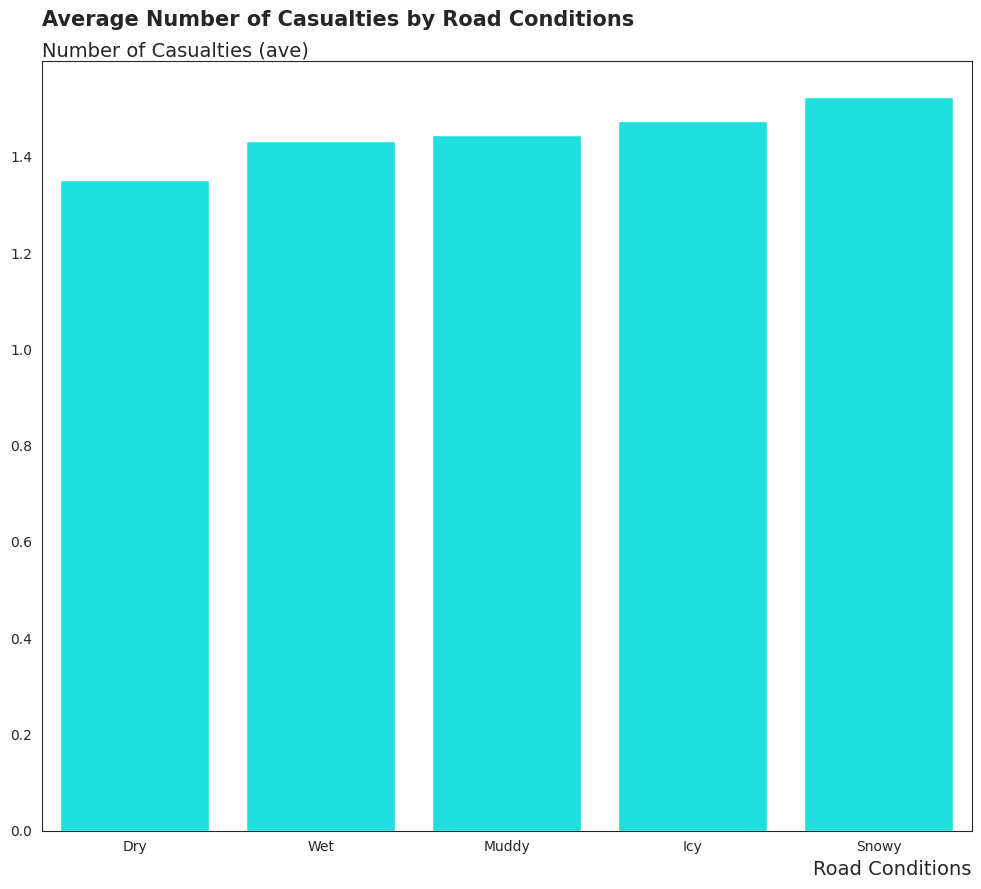

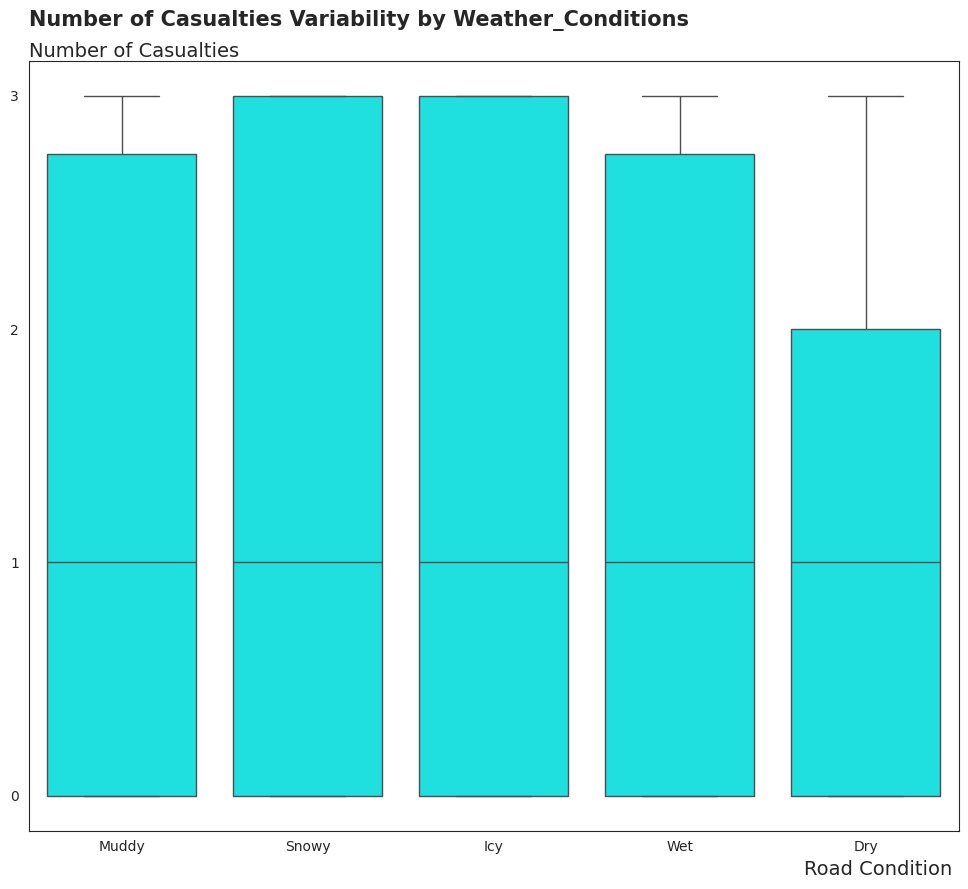

In [20]:
import seaborn as sns

## Grouping and sorting the data
avg_data = df.groupby('Road_Conditions')['Num_Casualties'].mean().sort_values(ascending=True).index


plt.figure(figsize=(12,10))
sns.set_style("white")
sns.barplot(data=df, x='Road_Conditions', y='Num_Casualties', order= avg_data , color='cyan', errorbar=None)

plt.title("Average Number of Casualties by Road Conditions", loc='left', pad=25, fontsize=15, fontweight='bold')

plt.ylabel("Number of Casualties (ave)", fontsize=14, rotation=0, loc='top', labelpad=-215)

plt.xlabel("Road Conditions", fontsize=14, loc='right')

plt.show()



plt.figure(figsize=(12, 10))
sns.boxplot(data=df, x='Road_Conditions', y='Num_Casualties'
            , color='cyan')
plt.title('Number of Casualties Variability by Weather_Conditions ', loc='left', pad=25,fontsize=15, fontweight='bold')
plt.ylabel("Number of Casualties", rotation=0, loc='top', labelpad=-165, fontsize=14)
plt.xlabel("Road Condition ", fontsize=14, loc='right')



ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(integer=True))


plt.show()

In [21]:
"""
Trends:
There is a clear upward trend in accident as road conditions transition from dry to snowy. Snowy and icy roads represent the highest risk, resulting in the peak average number of casualties per incident.

Patterns:
1. Each road condition category contains a similar number of records, ensuring the calculated averages are statistically comparable.
2. The graph reveals a predictable relationship where lower road friction directly corresponds to higher injury counts.


"""

'\nTrends:\nThere is a clear upward trend in accident as road conditions transition from dry to snowy. Snowy and icy roads represent the highest risk, resulting in the peak average number of casualties per incident.\n\nPatterns:\n1. Each road condition category contains a similar number of records, ensuring the calculated averages are statistically comparable.\n2. The graph reveals a predictable relationship where lower road friction directly corresponds to higher injury counts.\n\n\n'

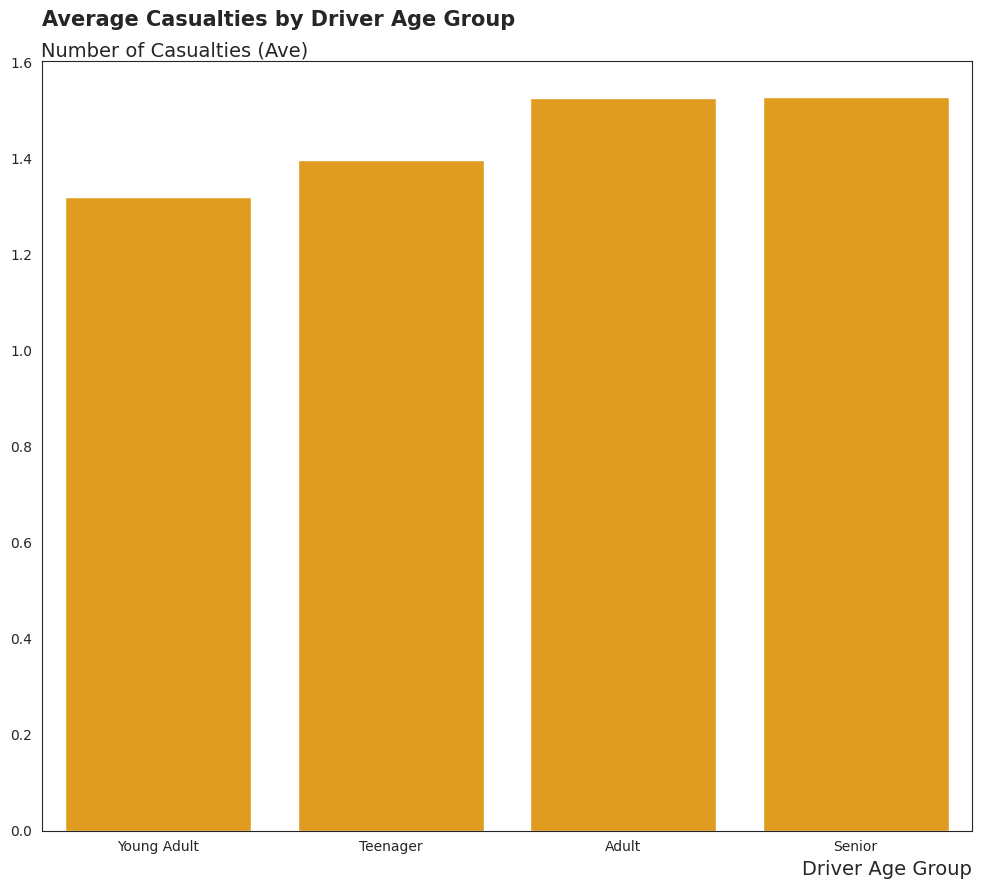

In [22]:



# 2. Us a NEW variable name (age_data) so you don't destroy your original 'df'
age_data = df.groupby('Driver_Age_Group')['Num_Casualties'].mean().reset_index()
age_data = age_data.sort_values('Num_Casualties', ascending=True)

# 3. Setup the plot
plt.figure(figsize=(12, 10))
sns.set_style("white")

# 4. Plot using age_data
sns.barplot(data=age_data, x='Driver_Age_Group', y='Num_Casualties', color= 'orange')

plt.title('Average Casualties by Driver Age Group', loc='left', pad=25, fontsize=15, fontweight='bold')

plt.ylabel('Number of Casualties (Ave)', fontsize=14,
           rotation=0, loc='top', labelpad=-215)

plt.xlabel('Driver Age Group', fontsize=14, loc='right')


plt.show()

In [23]:
"""
Trends:
There is a clear upward trend as we move from younger to older age groups. As the Driver Age Group increases in seniority, the Average Number of Casualties also rises. The trend isn't a sudden spike, it’s a steady climb.

Patterns:
Noticed a pattern where the Adult and Senior bars are very close in height compared to the jump from Teenager to Young Adult. This suggests a leveling off of accident severity once a driver reaches a certain maturity level.

"""

"\nTrends:\nThere is a clear upward trend as we move from younger to older age groups. As the Driver Age Group increases in seniority, the Average Number of Casualties also rises. The trend isn't a sudden spike, it’s a steady climb.\n\nPatterns:\nNoticed a pattern where the Adult and Senior bars are very close in height compared to the jump from Teenager to Young Adult. This suggests a leveling off of accident severity once a driver reaches a certain maturity level.\n\n"

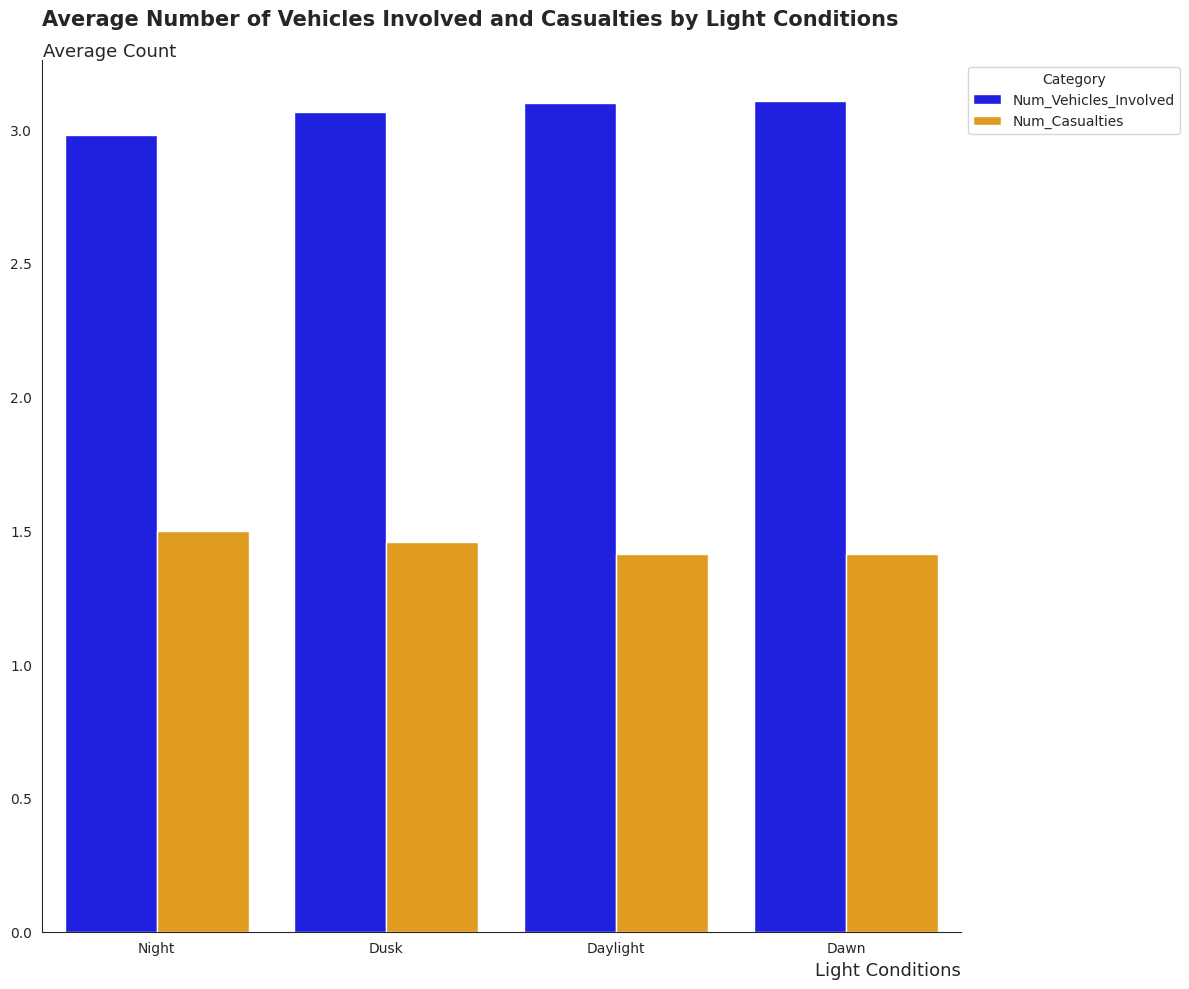

In [24]:


# 1. Grouping and sorting
Groupby = df.groupby('Light_Conditions')['Num_Vehicles_Involved'].mean().sort_values().index

# 2. Preparing data
df_melted = df.melt(id_vars=['Light_Conditions'],
                    value_vars=['Num_Vehicles_Involved', 'Num_Casualties'],
                    var_name='Category', value_name='Average Value')


plt.figure(figsize=(12, 10))
sns.set_style("white")


my_colors = {'Num_Vehicles_Involved': 'blue', 'Num_Casualties': 'orange'}

sns.barplot(data=df_melted, x='Light_Conditions', y='Average Value',
            hue='Category', order=Groupby, palette=my_colors, errorbar=None)

plt.title("Average Number of Vehicles Involved and Casualties by Light Conditions",
          loc='left', pad=25, fontsize=15, fontweight='bold')

plt.ylabel("Average Count", fontsize=13, rotation=0, loc='top', labelpad=-120)

plt.xlabel("Light Conditions", fontsize=13, loc='right')



plt.legend(title='Category', loc='upper left', bbox_to_anchor=(1, 1))

sns.despine()
plt.tight_layout()
plt.show()

In [25]:
"""

TRENDS:
1. During Night time accidents involve the less number of vehicles on average but result in the highest number of casualties, indicating a trend of increased severity during dark hours.
2. Accidents during Dawn and Daylight hours tend to involve the highest number of vehicles but yield lower casualty rates per incident.


PATTERNS:
1. Across all lighting conditions, there is a consistent pattern where the number of vehicles involved in an accident is approximately double the number of casualties.
2. A distinct pattern emerges where low-visibility conditions (Night and Dusk) consistently show higher casualty averages than high-visibility conditions (Dawn and Daylight).


"""

'\n\nTRENDS:\n1. During Night time accidents involve the less number of vehicles on average but result in the highest number of casualties, indicating a trend of increased severity during dark hours.\n2. Accidents during Dawn and Daylight hours tend to involve the highest number of vehicles but yield lower casualty rates per incident.\n\n\nPATTERNS:\n1. Across all lighting conditions, there is a consistent pattern where the number of vehicles involved in an accident is approximately double the number of casualties.\n2. A distinct pattern emerges where low-visibility conditions (Night and Dusk) consistently show higher casualty averages than high-visibility conditions (Dawn and Daylight).\n\n\n'

In [26]:
"""
Talking about what changed since week 5:
I changed the normal bar chart with average to boxplot because bar charts showing averages can be misleading if the data has a high variance. After getting critic on my visualization, I made changes on excessive use of color to one color, I have aligned the labels to reduce the cognitive load using the concept of minizingeye travel. And I relized that these graphs looks dull on the projectors screen so I increased the size of the graph with big font size of title and labels following the concept of mode of delivary of the graphs. I have deleted the scatterplot between visibility vs speed after it showed no relationship, suggesting that the people didnot care about the visibility.


"""

'\nTalking about what changed since week 5:\nI changed the normal bar chart with average to boxplot because bar charts showing averages can be misleading if the data has a high variance. After getting critic on my visualization, I made changes on excessive use of color to one color, I have aligned the labels to reduce the cognitive load using the concept of minizingeye travel. And I relized that these graphs looks dull on the projectors screen so I increased the size of the graph with big font size of title and labels following the concept of mode of delivary of the graphs. I have deleted the scatterplot between visibility vs speed after it showed no relationship, suggesting that the people didnot care about the visibility. \n\n\n'